# ___`corHMM` practice___
----------------------------

In [1]:
suppressPackageStartupMessages({
    library("ape")
    library("corHMM")
})

In [2]:
packageVersion("corHMM")

[1] '2.8'

In [3]:
# use the primates dataset for practice as demonstrated in the package vignette
data(primates)
tree <- ape::multi2di(primates[[1]])
data <- primates[[2]]

In [4]:
tree # 60 species


Phylogenetic tree with 60 tips and 59 internal nodes.

Tip labels:
  Homo_sapiens, Pan_paniscus, Pan_troglodytes, Gorilla_gorilla, Pongo_pygmaeus, Pongo_pygmaeus_abelii, ...

Rooted; includes branch length(s).

In [5]:
head(data) # two categorical traits
# T1 - presence or absence of estrus advertisement in females
# T2 - single or multimale mating systems

,Genus_sp,T1,T2
,<fct>,<int>,<int>
1,Cercocebus_torquatus,1,1
2,Cercopithecus_aethiops,0,1
3,Cercopithecus_mona,0,0
4,Cercopithecus_nictitans,0,0
5,Colobus_angolensis,0,1
6,Colobus_guereza,0,0


In [7]:
stopifnot(length(tree$tip.label) == dim(data)[1]) # good :)

In [8]:
# sort the dataset to match the species order in the phylogeny
data <- data[match(x = tree$tip.label, data$Genus_sp), ]
stopifnot(all.equal(data$Genus_sp, as.factor(tree$tip.label)))

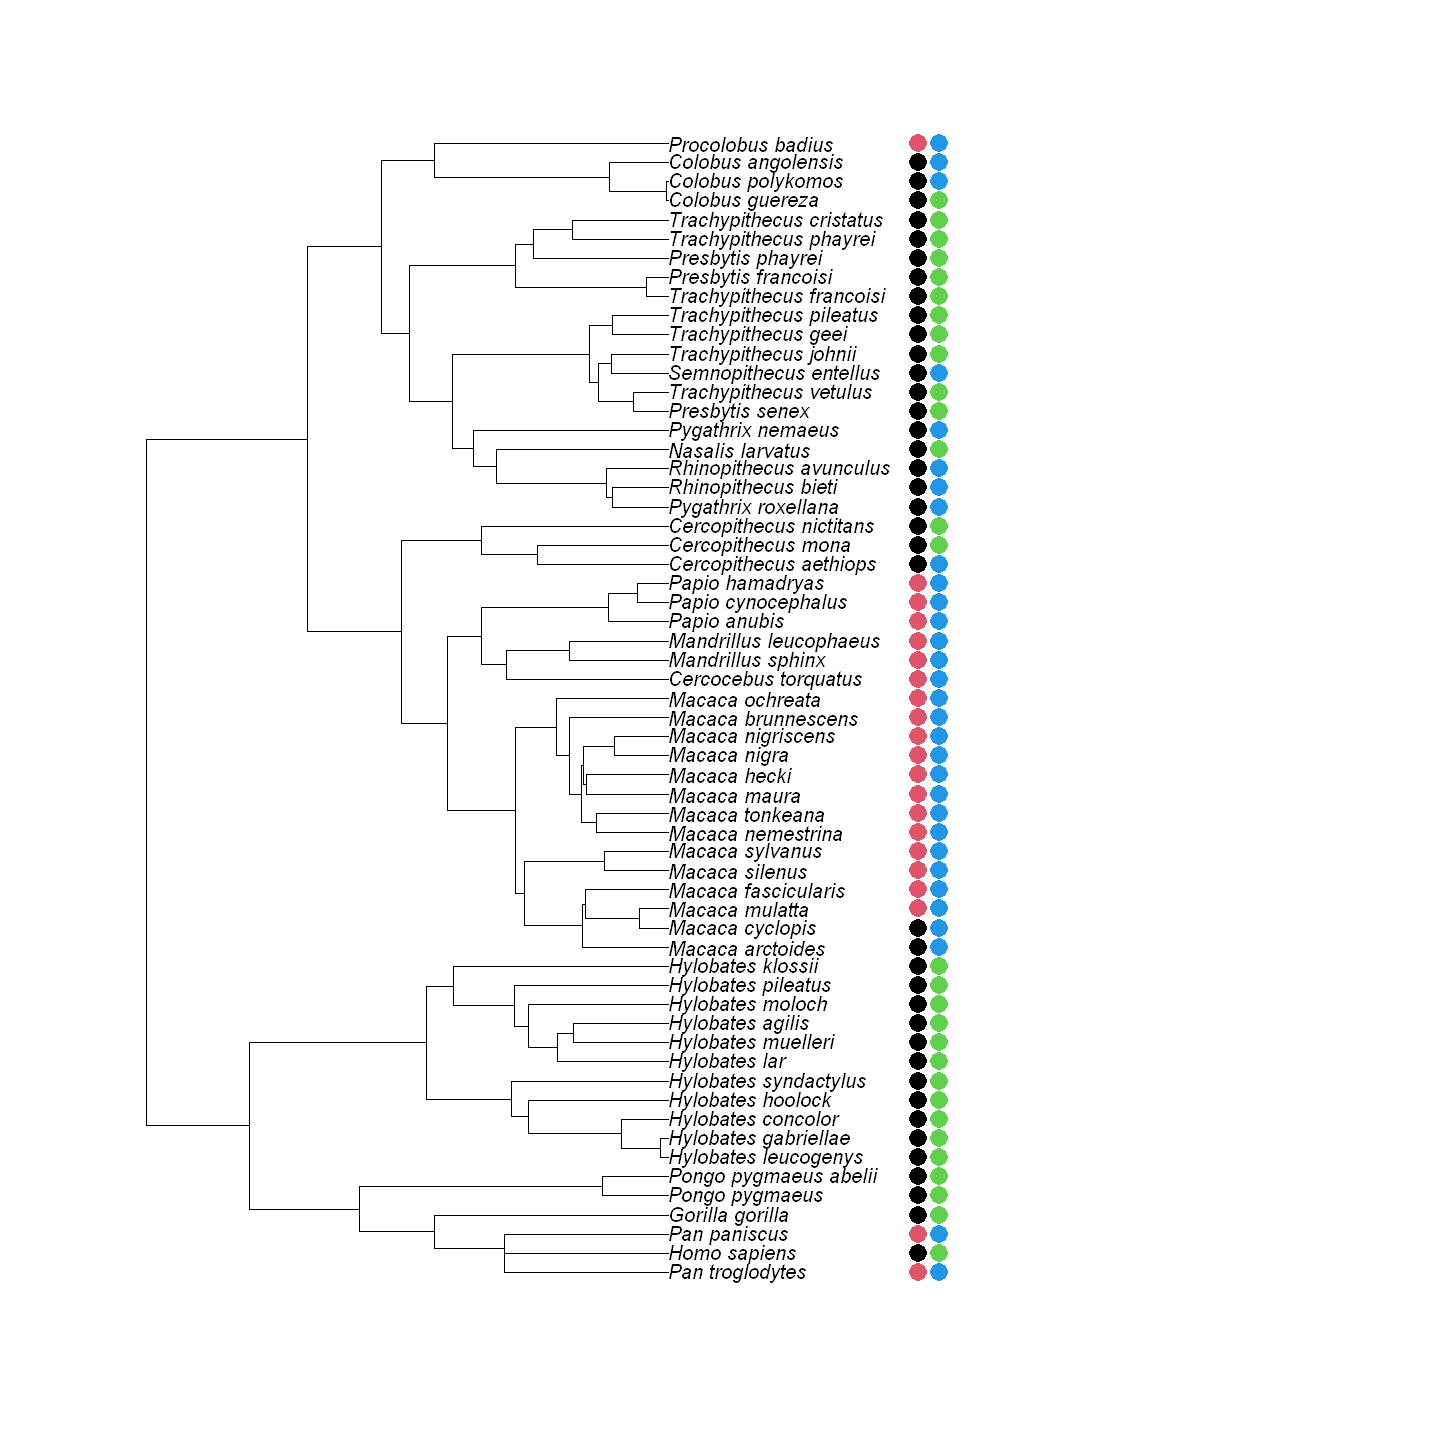

In [13]:
options(repr.plot.width = 12, repr.plot.height = 12)
plot(tree, show.tip.label = TRUE)
tiplabels(pch = 16, col = data$T1 + 1, cex = 2, offset = 24) # first column of circles - estrus advertisement in females
tiplabels(pch = 16, col = data$T2 + 3, cex = 2, offset = 26) # second column of circles - single male or multimale mating system

In [17]:
# the default for arg `model` is "ARD"
baseMM <- corHMM::corHMM(phy = tree, data = data, rate.cat = 1, model = "ARD") # no hidden states

Warning message in corHMM::corHMM(phy = tree, data = data, rate.cat = 1, model = "ARD"):
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	
Counts:	29	10	21	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 


In [54]:
baseMM # these are the corHMM outputs


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -41.90867 91.81734 92.54461        1   60

Legend
    1     2     3 
"0_0" "0_1" "1_1" 

Rates
           (1,R1)     (2,R1)     (3,R1)
(1,R1)         NA 0.01900076         NA
(2,R1) 0.05664411         NA 0.02627018
(3,R1)         NA 0.01610503         NA

Arrived at a reliable solution 

In [65]:
# even though we had two categorical traits with two states in each, we only see three transitions in the legend
# why is that??
print(unique(paste0(as.character(data$T1), '_', as.character(data$T2))))

[1] "0_0" "1_1" "0_1"


In [61]:
# it seems that not all the 4 possible combinations exist in our dataset, as simpla as that
# the legend is a multistate legend, e.g (3, R1) indicates state 1 in trait T1 and state 1 in trait T2 (look at the legend)

In [67]:
# we can also create and use the rate matrix manually, using our data which will take into consideration the multistate pairs that exist before generating the state transition matrix
print(corHMM::getStateMat4Dat(data))

$legend
    1     2     3 
"0_0" "0_1" "1_1" 

$rate.mat
    (1) (2) (3)
(1)   0   2   0
(2)   1   0   4
(3)   0   3   0



In [70]:
# the primary diagonal is zeroed out because they represent same state transitions which do not make any sense
# and all the four corners are also zeroed out because corHMM operates under the assumption that dual state transitins are not possible i.e 00 cannot go to 11 without going through 01 or 10
# at a transition, only one discrete trait can change (why????), hence all the transitions between 00 and 11 are zeroed out

In [20]:
# THIS IS THE Q (REGIME RATE MATRIX), WHAT WE SAW EARLIER WAS A STATE TRANSITION MATRIX WHICH CAN BE USED TO INTERPRET THE AXIES OF THE Q MATRIX
# A STATE TRANSITION MATRIX IN ITSELF DOESN'T CONTAIN ANY USEFUL INFORMATION

rates <- baseMM$solution
rates

,"(1,R1)","(2,R1)","(3,R1)"
"(1,R1)",NA,0.01899508,NA
"(2,R1)",0.05662512,NA,0.02626388
"(3,R1)",NA,0.01610149,NA


In [21]:
rates[is.na(rates)] <- 0 # replace NAs with zeroes for convenience
diag(rates) <- rowSums(rates) # replace the primary diagonal with rowsums, why????
rates

,"(1,R1)","(2,R1)","(3,R1)"
"(1,R1)",0.01899508,0.01899508,0.00000000
"(2,R1)",0.05662512,0.08288901,0.02626388
"(3,R1)",0.00000000,0.01610149,0.01610149


In [22]:
# corHMM::makeSimmap simulates the evolutionary history discrete character states, given an output of 
# corHMM() function (state transition rate matrix)

evhistory <- corHMM::makeSimmap(tree = tree, data = data, model = rates, rate.cat = 1, nSim = 1, nCores = 1)[[1]]

no colors provided. using the following legend:
      0_0       0_1       1_1 
  "black" "#DF536B" "#61D04F" 


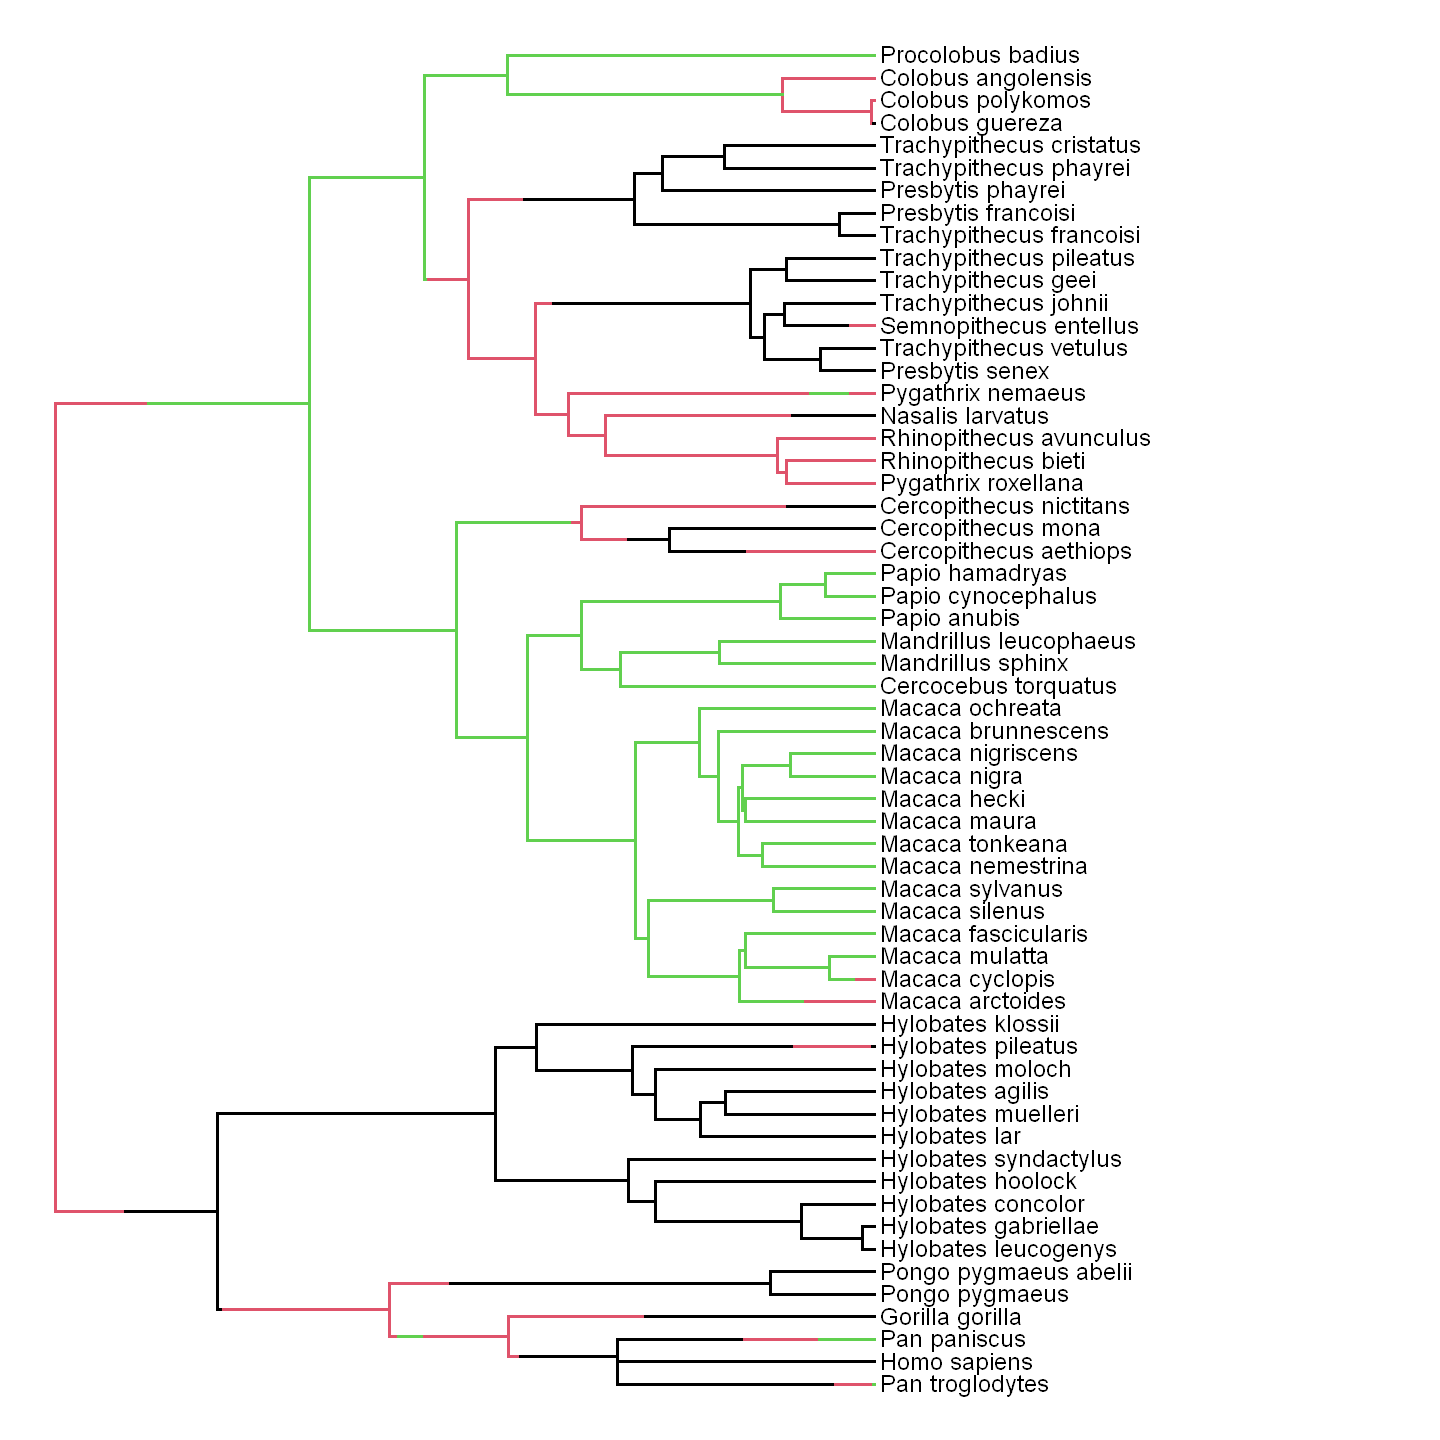

In [23]:
# this plot shows the evolutionary history of the multistate character (combination of two discrete character traits)
phytools::plotSimmap(tree = evhistory, fsize = 1.2, lwd = 2.5)

In [24]:
# now, let's look at including hidden Markov states
hiddenMM <- corHMM::corHMM(phy = tree, data = data, rate.cat = 2, model = "ARD", get.tip.states = TRUE)

Warning message in corHMM::corHMM(phy = tree, data = data, rate.cat = 2, model = "ARD", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	
Counts:	29	10	21	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 


In [ ]:
# LEARN TO VIEW THE RATES AS EVOLUTIONARY OR SELECTIVE PRESSURES

In [25]:
# under the all rates are are same ER situation, transitions WITHIN every pair of rate categories are kept constant
# IN OTHER WORDS, THERE ARE NO DISCRETE CHARACTER STATE DEPENDENT TRANSITION RATE DIFFERENCES
# ER does not mean EVERY transition rate will be identical, ONLY WITHIN RATE CATEGORY PAIR TRANSITION RATES
# e.g. all transitions happening from R1 to R1 will be identical, so are transitions from R1 to R2; from R2 to R1 and R2 to R2

# in this example, all 
# all R1 -> R1 transitions have a rate of 4.84341645
# all R2 -> R1 transitions have a rate of 0.01504712
# all R1 -> R2 transitions have a rate of 0.062918790
# all R2 -> R2 transitions have a rate of 0.002647026

hiddenMM 


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -40.56454 101.1291 105.6189        2   60

Legend
    1     2     3 
"0_0" "0_1" "1_1" 

Rates
           (1,R1)      (2,R1)      (3,R1)     (1,R2)      (2,R2)     (3,R2)
(1,R1)         NA 0.008827179          NA 0.01165445          NA         NA
(2,R1) 0.05740739          NA 0.000000001         NA 0.011654452         NA
(3,R1)         NA 0.092661966          NA         NA          NA 0.01165445
(1,R2) 0.03126972          NA          NA         NA 0.084322348         NA
(2,R2)         NA 0.031269719          NA 0.05740739          NA 0.36807165
(3,R2)         NA          NA 0.031269719         NA 0.000000001         NA

Arrived at a reliable solution 

In [102]:
# under the symmetric rates situation, transition rates between symmetric pairs of multistates will be identical
# HERE WE DO HAVE WITHIN RATE CATEGORY PAIR RATE DIFFERENCES

# e.g. when considering the rate category pairs R1 to R1;
# (1, R1) to (2, R1) - 9.831876131
# (2, R1) to (1, R1) - 9.83187613
# these two rates are identical as these are symmetric transitions (1 to 2 and 2 to 1) occuring within the same rate category

# but these will be different from the same symmetric transitions happening under rate category 2
# (1, R2) to (2, R2) - 0.000000001
# (2, R2) to (1, R2) - 0.000000001 
# THESE ARE IDENTICAL AMONG THEMSELVES BUT NOT IDENTICAL TO THE SAME TRANSITIONS UNDER THE OTHER RATE CATEGORY

# SEE THE MULTISTATE DEPENDENT TRANSITION RATE DIFFERENCES WITHIN RATE CATEGORY PAIRS
hiddenMMSYM


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -41.54584 95.09167 96.67658        2   60

Legend
    1     2     3 
"0_0" "0_1" "1_1" 

Rates
           (1,R1)      (2,R1)      (3,R1)      (1,R2)      (2,R2)     (3,R2)
(1,R1)         NA 9.831876131          NA 0.016085579          NA         NA
(2,R1) 9.83187613          NA 0.009959472          NA 0.016085579         NA
(3,R1)         NA 0.009959472          NA          NA          NA 0.01608558
(1,R2) 0.01173114          NA          NA          NA 0.000000001         NA
(2,R2)         NA 0.011731137          NA 0.000000001          NA 0.31774771
(3,R2)         NA          NA 0.011731137          NA 0.317747712         NA

Arrived at a reliable solution 

In [104]:
hiddenMMARD


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -38.58571 97.17142 101.6612        2   60

Legend
    1     2     3 
"0_0" "0_1" "1_1" 

Rates
            (1,R1)      (2,R1)     (3,R1)     (1,R2)      (2,R2)      (3,R2)
(1,R1)          NA 8.678275971         NA 0.02492172          NA          NA
(2,R1) 16.48642097          NA 0.04943747         NA 0.024921721          NA
(3,R1)          NA 0.000000001         NA         NA          NA 0.024921721
(1,R2)  0.01626872          NA         NA         NA 0.000000001          NA
(2,R2)          NA 0.016268723         NA 0.03954356          NA 0.000000001
(3,R2)          NA          NA 0.01626872         NA 0.073769020          NA

Arrived at a reliable solution 

In [ ]:
# THERE WILL NEVER BE A CROSS RATE CATEGORY PAIR RATE SIMILARITY!!!!
# ER, SYM & ARD ALL APPLY WITHIN RATE CATEGORY PAIRS OF FROM AND TO MULTI STATES